In [3]:
pip install numpy pandas matplotlib seaborn scikit-learn scipy

CHARGEMENT DU DATASET PIMA INDIAN DIABETES
✓ Données chargées depuis fichier CSV

INFORMATIONS GÉNÉRALES

Nombre d'observations : 768
Nombre de variables : 9

Nom des colonnes :
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

APERÇU DES PREMIÈRES LIGNES
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   
5            5      116             74              0        0  25.6   
6            3       78             50             32       88  31.0   
7           10      115              0              0        0  35.3   
8            2      

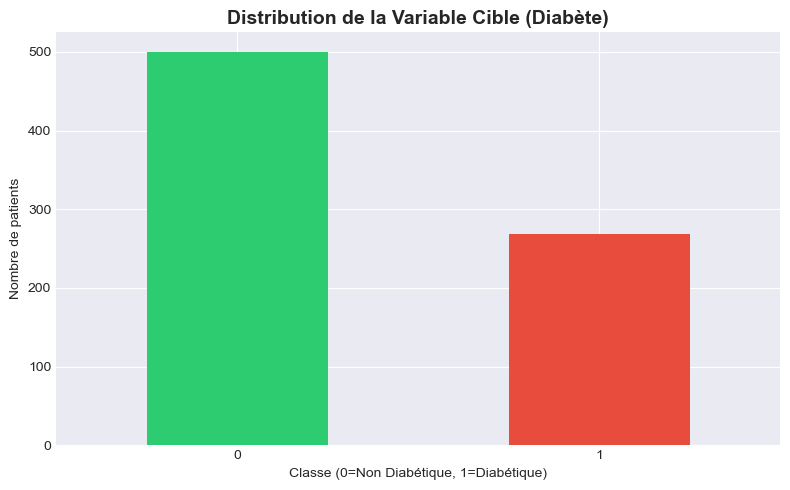


✓ Données sauvegardées dans 'diabetes_raw.csv'

CHARGEMENT TERMINÉ - Passez à l'Étape 3 (Analyse Uni-variée)


In [7]:
# Étape 2 : Acquisition et Première Exploration des Données
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. CHARGEMENT DES DONNÉES
print("="*60)
print("CHARGEMENT DU DATASET PIMA INDIAN DIABETES")
print("="*60)

# Chargement depuis fichier CSV local
df = pd.read_csv(r"C:\Users\alima\Downloads\diabetes.csv")
print("✓ Données chargées depuis fichier CSV")

# 2. INFORMATION GÉNÉRALE SUR LE DATASET
print("\n" + "="*60)
print("INFORMATIONS GÉNÉRALES")
print("="*60)
print(f"\nNombre d'observations : {df.shape[0]}")
print(f"Nombre de variables : {df.shape[1]}")
print(f"\nNom des colonnes :")
print(df.columns.tolist())

# 3. APERÇU DES DONNÉES
print("\n" + "="*60)
print("APERÇU DES PREMIÈRES LIGNES")
print("="*60)
print(df.head(10))

# 4. TYPES DE DONNÉES
print("\n" + "="*60)
print("TYPES DE DONNÉES")
print("="*60)
print(df.dtypes)

# 5. STATISTIQUES DESCRIPTIVES
print("\n" + "="*60)
print("STATISTIQUES DESCRIPTIVES")
print("="*60)
print(df.describe())

# 6. VALEURS MANQUANTES
print("\n" + "="*60)
print("VALEURS MANQUANTES")
print("="*60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_table = pd.DataFrame({
    'Valeurs Manquantes': missing,
    'Pourcentage (%)': missing_pct
})
print(missing_table)

# 7. DISTRIBUTION DE LA VARIABLE CIBLE
print("\n" + "="*60)
print("DISTRIBUTION DE LA VARIABLE CIBLE (Outcome/Class)")
print("="*60)
target_col = 'class' if 'class' in df.columns else 'Outcome'
if target_col in df.columns:
    print(df[target_col].value_counts())
    print("\nPourcentage :")
    print(df[target_col].value_counts(normalize=True) * 100)
    
    # Visualisation
    plt.figure(figsize=(8, 5))
    df[target_col].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
    plt.title('Distribution de la Variable Cible (Diabète)', fontsize=14, fontweight='bold')
    plt.xlabel('Classe (0=Non Diabétique, 1=Diabétique)')
    plt.ylabel('Nombre de patients')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# 8. SAUVEGARDE DES INFORMATIONS
df.to_csv('diabetes_raw.csv', index=False)
print("\n✓ Données sauvegardées dans 'diabetes_raw.csv'")

print("\n" + "="*60)
print("CHARGEMENT TERMINÉ - Passez à l'Étape 3 (Analyse Uni-variée)")
print("="*60)

                         ANALYSE UNI-VARIÉE

Nombre de variables : 8
Variables analysées : Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
Nombre d'observations : 768

VARIABLE : Pregnancies

A. STATISTIQUES DESCRIPTIVES :
--------------------------------------------------
   Moyenne               : 3.845
   Médiane               : 3.000
   Mode                  : 1.000
   Écart-type            : 3.370
   Variance              : 11.354
   Minimum               : 0.000
   Maximum               : 17.000
   Étendue (Max - Min)   : 17.000

B. QUARTILES ET PERCENTILES :
--------------------------------------------------
   Q1 (25%)              : 1.000
   Q2 (50% - Médiane)    : 3.000
   Q3 (75%)              : 6.000
   IQR (Q3 - Q1)         : 5.000
   P10 (10%)             : 0.000
   P90 (90%)             : 9.000

C. MESURES DE FORME :
--------------------------------------------------
   Asymétrie (Skewness)  : 0.902
      → Distribution ASY

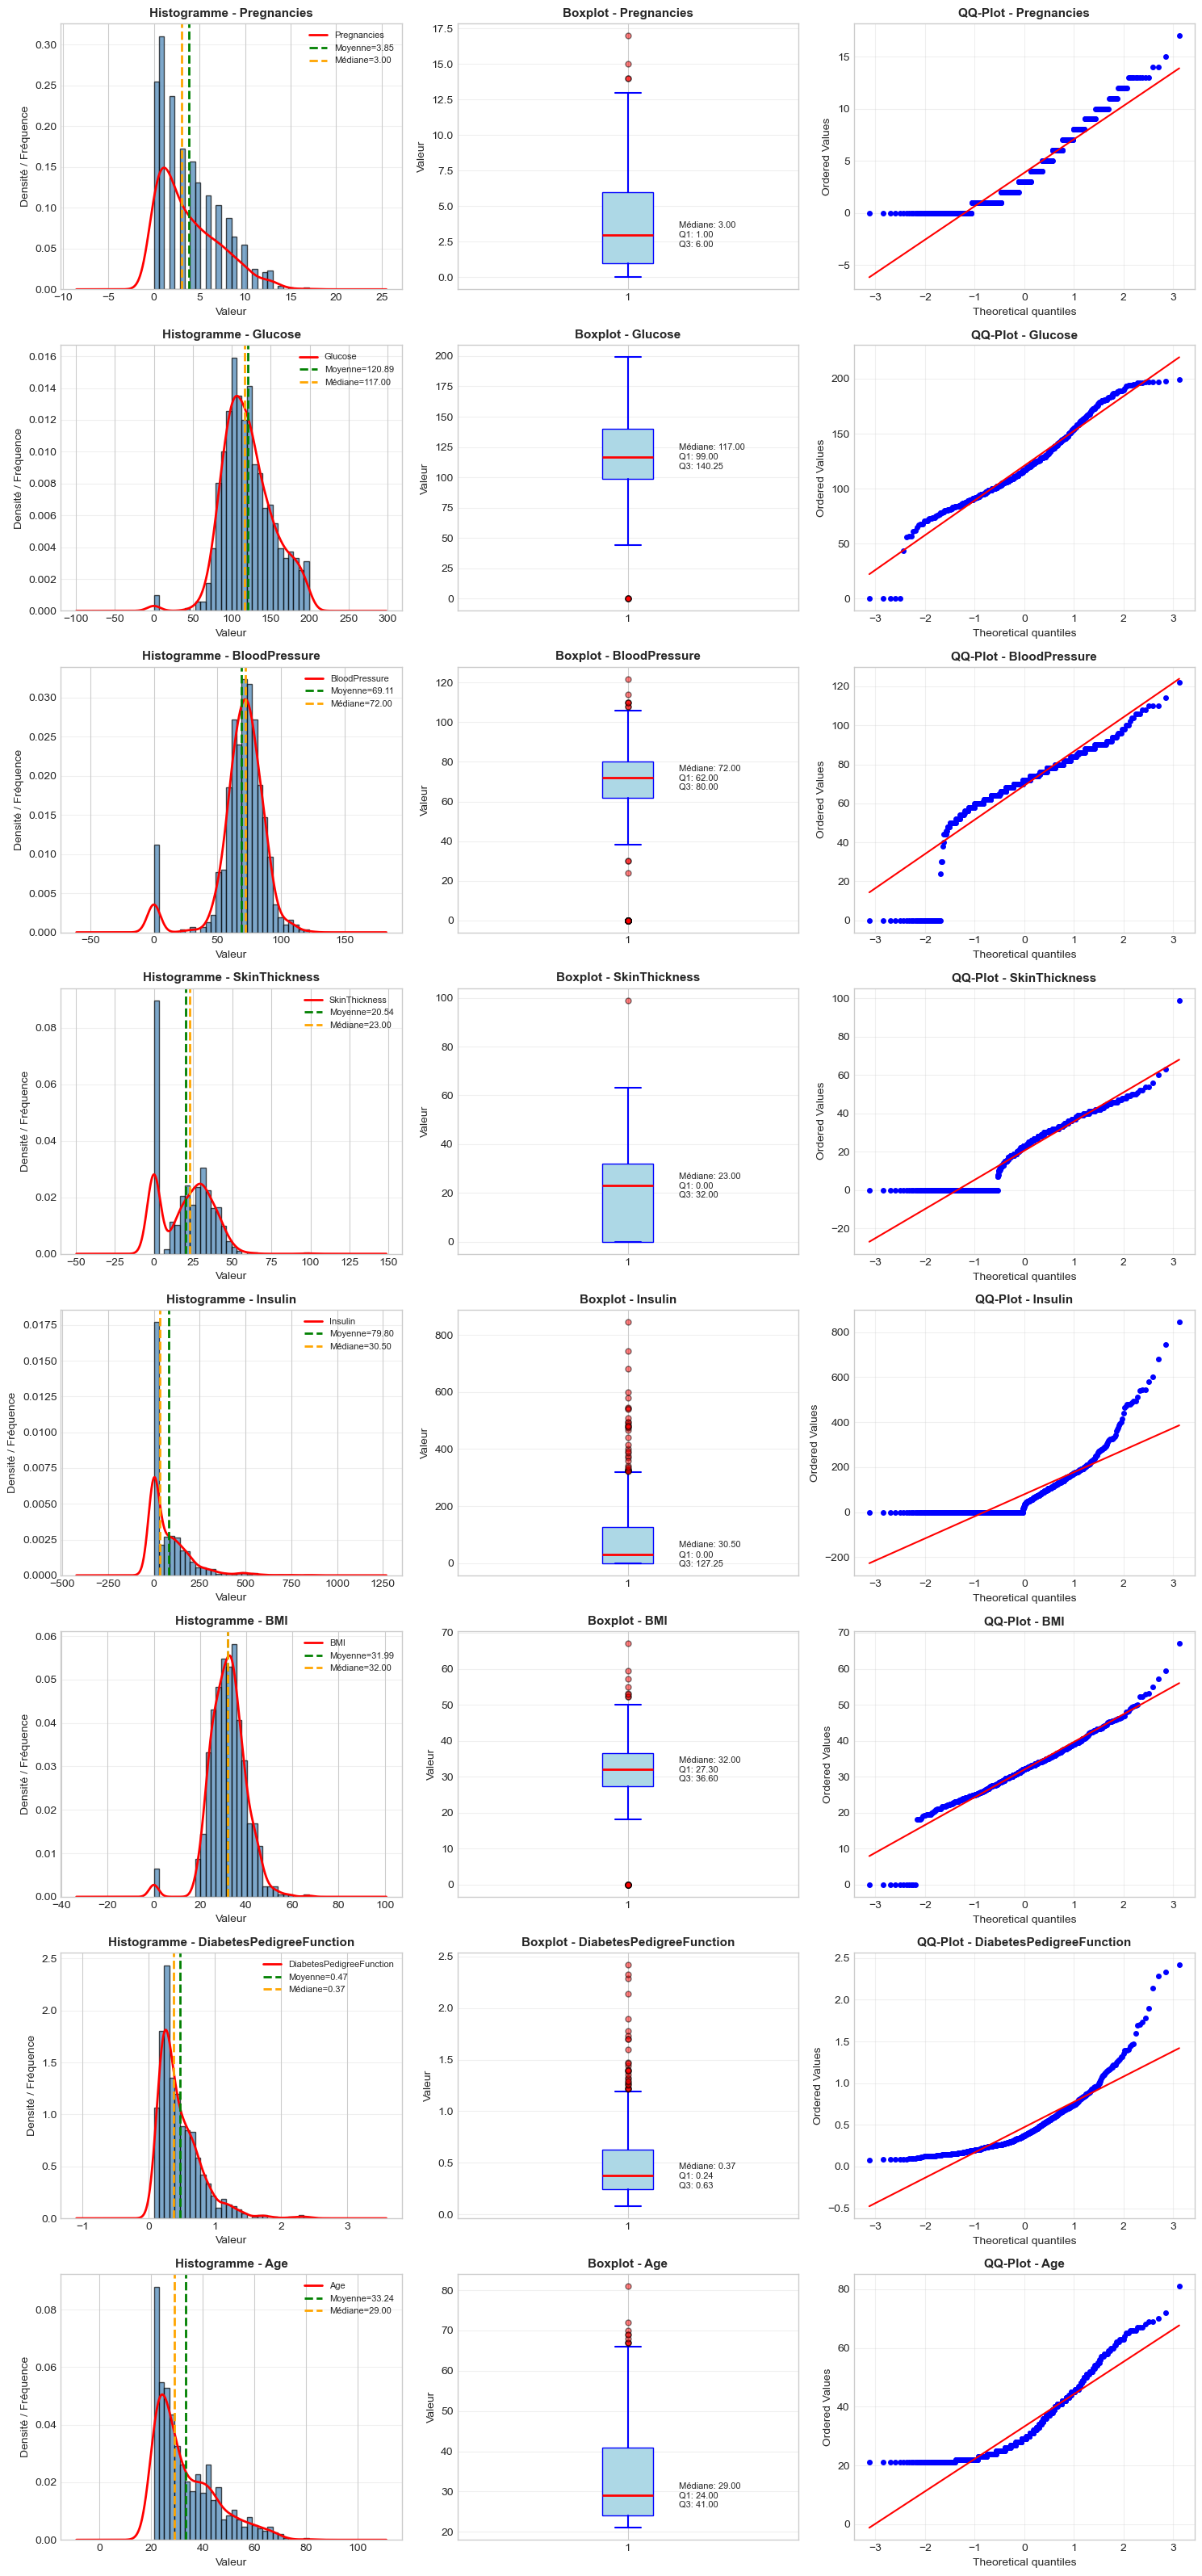


                    TABLEAU RÉCAPITULATIF DES STATISTIQUES

                 Variable  Moyenne  Médiane  Écart-type  Asymétrie  Aplatissement  Outliers  Outliers (%)  Zéros  p-value Normal.
             Pregnancies    3.845    3.000       3.370      0.902          0.159         4         0.521    111              0.0
                 Glucose  120.895  117.000      31.973      0.174          0.641         5         0.651      5              0.0
           BloodPressure   69.105   72.000      19.356     -1.844          5.180        45         5.859     35              0.0
           SkinThickness   20.536   23.000      15.952      0.109         -0.520         1         0.130    227              0.0
                 Insulin   79.799   30.500     115.244      2.272          7.214        34         4.427    374              0.0
                     BMI   31.993   32.000       7.884     -0.429          3.290        19         2.474     11              0.0
DiabetesPedigreeFunction    0.472  

In [16]:
# ============================================================
# ÉTAPE 3 : ANALYSE UNI-VARIÉE COMPLÈTE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Chargement des données
df = pd.read_csv('diabetes_raw.csv')

# Identification des colonnes numériques (sauf la cible)
target_col = 'Outcome'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

print("="*80)
print(" "*25 + "ANALYSE UNI-VARIÉE")
print("="*80)
print(f"\nNombre de variables : {len(numeric_cols)}")
print(f"Variables analysées : {', '.join(numeric_cols)}")
print(f"Nombre d'observations : {len(df)}")

# ================================================================
# 1. MESURES STATISTIQUES PAR VARIABLE
# ================================================================

def analyze_variable(data, col_name):
    """Analyse complète d'une variable numérique"""
    print(f"\n{'='*80}")
    print(f"VARIABLE : {col_name}")
    print(f"{'='*80}")
    
    valeurs = data[col_name].dropna()
    
    # --- A. STATISTIQUES DESCRIPTIVES ---
    print("\nA. STATISTIQUES DESCRIPTIVES :")
    print("-" * 50)
    moyenne = valeurs.mean()
    mediane = valeurs.median()
    mode_vals = valeurs.mode()
    mode = mode_vals.values[0] if len(mode_vals) > 0 else np.nan
    
    print(f"   Moyenne               : {moyenne:.3f}")
    print(f"   Médiane               : {mediane:.3f}")
    print(f"   Mode                  : {mode:.3f}")
    print(f"   Écart-type            : {valeurs.std():.3f}")
    print(f"   Variance              : {valeurs.var():.3f}")
    print(f"   Minimum               : {valeurs.min():.3f}")
    print(f"   Maximum               : {valeurs.max():.3f}")
    print(f"   Étendue (Max - Min)   : {valeurs.max() - valeurs.min():.3f}")
    
    # --- B. QUARTILES ET PERCENTILES ---
    print("\nB. QUARTILES ET PERCENTILES :")
    print("-" * 50)
    q1 = valeurs.quantile(0.25)
    q2 = valeurs.quantile(0.50)
    q3 = valeurs.quantile(0.75)
    iqr = q3 - q1
    
    print(f"   Q1 (25%)              : {q1:.3f}")
    print(f"   Q2 (50% - Médiane)    : {q2:.3f}")
    print(f"   Q3 (75%)              : {q3:.3f}")
    print(f"   IQR (Q3 - Q1)         : {iqr:.3f}")
    print(f"   P10 (10%)             : {valeurs.quantile(0.10):.3f}")
    print(f"   P90 (90%)             : {valeurs.quantile(0.90):.3f}")
    
    # --- C. MESURES DE FORME ---
    print("\nC. MESURES DE FORME :")
    print("-" * 50)
    skew = valeurs.skew()
    kurt = valeurs.kurtosis()
    
    print(f"   Asymétrie (Skewness)  : {skew:.3f}")
    if abs(skew) < 0.5:
        print("      → Distribution relativement SYMÉTRIQUE")
    elif skew > 0.5:
        print("      → Distribution ASYMÉTRIQUE À DROITE (queue vers la droite)")
    else:
        print("      → Distribution ASYMÉTRIQUE À GAUCHE (queue vers la gauche)")
    
    print(f"\n   Aplatissement (Kurtosis) : {kurt:.3f}")
    if kurt > 0:
        print("      → Distribution LEPTOKURTIQUE (plus pointue)")
    elif kurt < 0:
        print("      → Distribution PLATYKURTIQUE (plus aplatie)")
    else:
        print("      → Distribution MÉSOKURTIQUE (normale)")
    
    # --- D. TEST DE NORMALITÉ ---
    print("\nD. TEST DE NORMALITÉ :")
    print("-" * 50)
    if len(valeurs) >= 3:
        stat_shapiro, p_shapiro = shapiro(valeurs)
        print(f"   Test de Shapiro-Wilk")
        print(f"      Statistique W      : {stat_shapiro:.4f}")
        print(f"      p-value            : {p_shapiro:.4f}")
        if p_shapiro > 0.05:
            print("      → Distribution NORMALE (p > 0.05)")
        else:
            print("      → Distribution NON NORMALE (p ≤ 0.05)")
    
    # --- E. DÉTECTION DES VALEURS ABERRANTES ---
    print("\nE. VALEURS ABERRANTES (Méthode IQR) :")
    print("-" * 50)
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = valeurs[(valeurs < lower_bound) | (valeurs > upper_bound)]
    n_outliers = len(outliers)
    pct_outliers = (n_outliers / len(valeurs)) * 100
    
    print(f"   Limite inférieure     : {lower_bound:.3f}")
    print(f"   Limite supérieure     : {upper_bound:.3f}")
    print(f"   Nombre d'outliers     : {n_outliers} ({pct_outliers:.2f}%)")
    
    if n_outliers > 0:
        print(f"   Quelques valeurs aberrantes : {sorted(outliers.values)[:5]}")
    
    # --- F. DISTRIBUTION DES FRÉQUENCES ---
    print("\nF. DISTRIBUTION DES FRÉQUENCES :")
    print("-" * 50)
    
    # Création de classes (bins)
    n_bins = min(10, int(np.sqrt(len(valeurs))))
    bins = pd.cut(valeurs, bins=n_bins, include_lowest=True)
    
    # Tableau de fréquences
    freq_counts = bins.value_counts().sort_index()
    freq_table = pd.DataFrame({
        'Classe': freq_counts.index.astype(str),
        'Effectif': freq_counts.values,
        'Fréquence (%)': (freq_counts.values / len(valeurs)) * 100,
        'Effectif Cumulé': freq_counts.cumsum().values,
        'Fréq. Cumul. (%)': (freq_counts.cumsum().values / len(valeurs)) * 100
    })
    
    print("\n", freq_table.to_string(index=False))
    
    # --- G. VALEURS SPÉCIALES ---
    print("\nG. ANALYSE DES VALEURS SPÉCIALES :")
    print("-" * 50)
    n_missing = data[col_name].isnull().sum()
    n_zeros = (data[col_name] == 0).sum()
    n_unique = data[col_name].nunique()
    
    print(f"   Valeurs manquantes    : {n_missing} ({(n_missing/len(data))*100:.2f}%)")
    print(f"   Valeurs égales à 0    : {n_zeros} ({(n_zeros/len(data))*100:.2f}%)")
    print(f"   Valeurs uniques       : {n_unique}")
    
    if col_name in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'] and n_zeros > 0:
        print("   ATTENTION : Les zéros ont être considérés comme valeurs manquantes!")
    
    return {
        'mean': moyenne,
        'median': mediane,
        'std': valeurs.std(),
        'skew': skew,
        'kurtosis': kurt,
        'n_outliers': n_outliers,
        'pct_outliers': pct_outliers,
        'n_zeros': n_zeros,
        'p_value_normalite': p_shapiro if len(valeurs) >= 3 else np.nan
    }

# Analyse de toutes les variables
stats_summary = {}
for col in numeric_cols:
    stats_summary[col] = analyze_variable(df, col)

# ================================================================
# 2. VISUALISATIONS
# ================================================================

print("\n\n" + "="*80)
print(" "*20 + "CRÉATION DES VISUALISATIONS")
print("="*80)

n_vars = len(numeric_cols)
fig = plt.figure(figsize=(15, 4*n_vars))

for idx, col in enumerate(numeric_cols):
    # Histogramme avec courbe de densité
    ax1 = plt.subplot(n_vars, 3, idx*3 + 1)
    ax1.hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7, density=True)
    
    # Ajouter une courbe de densité
    df[col].plot(kind='kde', ax=ax1, color='red', linewidth=2, secondary_y=False)
    
    # Ajouter moyenne et médiane
    ax1.axvline(df[col].mean(), color='green', linestyle='--', linewidth=2, label=f'Moyenne={df[col].mean():.2f}')
    ax1.axvline(df[col].median(), color='orange', linestyle='--', linewidth=2, label=f'Médiane={df[col].median():.2f}')
    
    ax1.set_title(f'Histogramme - {col}', fontweight='bold', fontsize=11)
    ax1.set_xlabel('Valeur')
    ax1.set_ylabel('Densité / Fréquence')
    ax1.legend(fontsize=8)
    ax1.grid(axis='y', alpha=0.3)
    
    # Boxplot
    ax2 = plt.subplot(n_vars, 3, idx*3 + 2)
    bp = ax2.boxplot(df[col], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', color='blue'),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(color='blue', linewidth=1.5),
                     capprops=dict(color='blue', linewidth=1.5),
                     flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.5))
    
    ax2.set_title(f'Boxplot - {col}', fontweight='bold', fontsize=11)
    ax2.set_ylabel('Valeur')
    ax2.grid(axis='y', alpha=0.3)
    
    # Ajouter statistiques sur le boxplot
    stats_text = f"Médiane: {df[col].median():.2f}\nQ1: {df[col].quantile(0.25):.2f}\nQ3: {df[col].quantile(0.75):.2f}"
    ax2.text(1.15, df[col].median(), stats_text, fontsize=8, verticalalignment='center')
    
    # QQ-Plot
    ax3 = plt.subplot(n_vars, 3, idx*3 + 3)
    stats.probplot(df[col], dist="norm", plot=ax3)
    ax3.set_title(f'QQ-Plot - {col}', fontweight='bold', fontsize=11)
    ax3.grid(alpha=0.3)
    ax3.get_lines()[0].set_markerfacecolor('blue')
    ax3.get_lines()[0].set_markersize(4)

plt.tight_layout()
plt.savefig('analyse_univariee2.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualisations sauvegardées dans 'analyse_univariee2.png'")
plt.show()

# ================================================================
# 3. TABLEAU RÉCAPITULATIF
# ================================================================

print("\n" + "="*80)
print(" "*20 + "TABLEAU RÉCAPITULATIF DES STATISTIQUES")
print("="*80)

summary_df = pd.DataFrame({
    'Variable': numeric_cols,
    'Moyenne': [stats_summary[col]['mean'] for col in numeric_cols],
    'Médiane': [stats_summary[col]['median'] for col in numeric_cols],
    'Écart-type': [stats_summary[col]['std'] for col in numeric_cols],
    'Asymétrie': [stats_summary[col]['skew'] for col in numeric_cols],
    'Aplatissement': [stats_summary[col]['kurtosis'] for col in numeric_cols],
    'Outliers': [stats_summary[col]['n_outliers'] for col in numeric_cols],
    'Outliers (%)': [stats_summary[col]['pct_outliers'] for col in numeric_cols],
    'Zéros': [stats_summary[col]['n_zeros'] for col in numeric_cols],
    'p-value Normal.': [stats_summary[col]['p_value_normalite'] for col in numeric_cols]
})

print("\n", summary_df.round(3).to_string(index=False))

summary_df.to_csv('statistiques_univariees2.csv', index=False)
print("\n✓ Tableau sauvegardé dans 'statistiques_univariees2.csv'")

# ================================================================
# 4. RÉSUMÉ FINAL
# ================================================================

print("\n" + "="*80)
print(" "*25 + "RÉSUMÉ DE L'ANALYSE")
print("="*80)

print("\nVARIABLES AVEC DISTRIBUTION NORMALE (p > 0.05) :")
vars_normales = [col for col in numeric_cols if stats_summary[col]['p_value_normalite'] > 0.05]
if vars_normales:
    for var in vars_normales:
        print(f"   - {var} (p = {stats_summary[var]['p_value_normalite']:.4f})")
else:
    print("   Aucune variable ne suit une distribution normale")

print("\nVARIABLES AVEC OUTLIERS SIGNIFICATIFS (> 5%) :")
vars_outliers = [col for col in numeric_cols if stats_summary[col]['pct_outliers'] > 5]
if vars_outliers:
    for var in vars_outliers:
        print(f"   - {var} : {stats_summary[var]['n_outliers']} outliers ({stats_summary[var]['pct_outliers']:.2f}%)")
else:
    print("   Aucune variable avec outliers significatifs")

print("\nVARIABLES AVEC ZÉROS SUSPECTS :")
vars_zeros = [col for col in numeric_cols if stats_summary[col]['n_zeros'] > 0 and 
              col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']]
if vars_zeros:
    for var in vars_zeros:
        print(f"   - {var} : {stats_summary[var]['n_zeros']} zéros")
else:
    print("   Aucun zéro suspect détecté")

print("\n" + "="*80)
print(" "*20 + "ANALYSE UNI-VARIÉE TERMINÉE")
print("="*80)
print("\nFICHIERS GÉNÉRÉS :")
print("   1. analyse_univariee2.png")
print("   2. statistiques_univariees2.csv")
print("\nProchaine étape : Analyse bivariée")
print("="*80)


####################################################################################################
                                   RAPPORT D'ANALYSE BI-VARIÉE APPROFONDIE
####################################################################################################
Dataset : Pima Indians Diabetes | Variable Cible : 'Outcome' (Classification Binaire)
Variables Explicatives (Numériques) : 8
Variables : Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
####################################################################################################


PARTIE 1 : ANALYSE DE LA MULTICOLINÉARITÉ (Variables Explicatives)

1.1 MATRICE DE CORRÉLATION DE PEARSON (Relation Linéaire) :
                          Pregnancies  Glucose  BloodPressure  SkinThickness  \
Pregnancies                     1.000    0.128          0.208          0.082   
Glucose                         0.128    1.000          0.225          0.193   
BloodPressure    

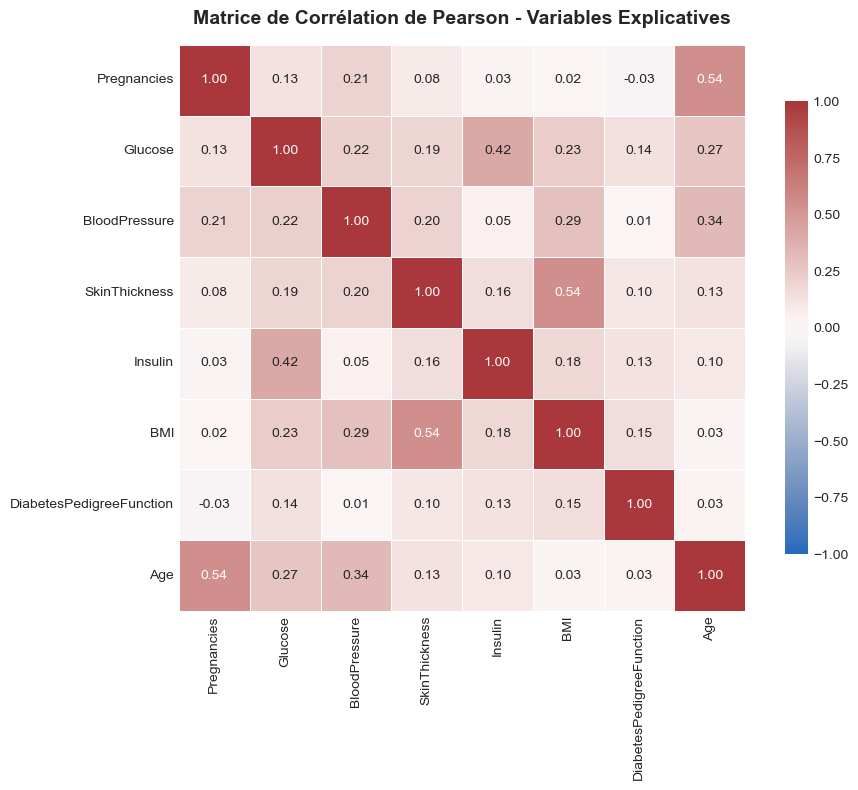


[Image de la Matrice de Corrélation de Pearson des variables explicatives]

2. PAIRES DE VARIABLES FORTEMENT CORRÉLÉES (|r| > 0.7) :
   -> Aucune corrélation forte détectée (|r| > 0.7). Faible risque de multicolinéarité sévère.

3. DENDROGRAMME : Identification des groupes de variables fortement liées


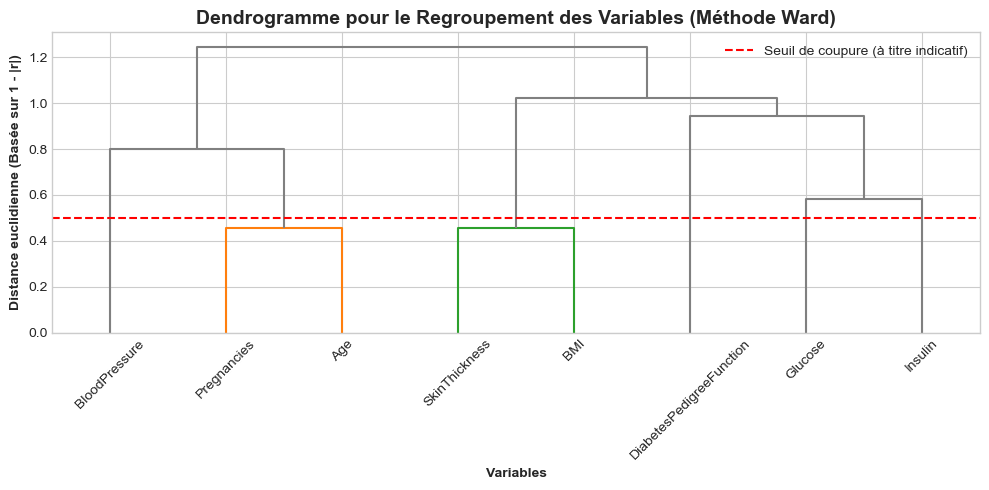


[Image du Dendrogramme pour le regroupement des variables explicatives]

PARTIE 2 : IMPACT DES VARIABLES SUR LA CIBLE (Diabète)

1. CORRÉLATION DE PEARSON AVEC LA VARIABLE CIBLE ('Outcome') :
   H0 : Corrélation Linéaire Nulle (r = 0)
  • Pregnancies          | r:   0.222 | p-value: 0.000000 | Très Hautement Significatif (***)   | REJET de H0
  • Glucose              | r:   0.493 | p-value: 0.000000 | Très Hautement Significatif (***)   | REJET de H0
  • BloodPressure        | r:   0.171 | p-value: 0.000002 | Très Hautement Significatif (***)   | REJET de H0
  • SkinThickness        | r:   0.215 | p-value: 0.000000 | Très Hautement Significatif (***)   | REJET de H0
  • Insulin              | r:   0.204 | p-value: 0.000000 | Très Hautement Significatif (***)   | REJET de H0
  • BMI                  | r:   0.312 | p-value: 0.000000 | Très Hautement Significatif (***)   | REJET de H0
  • DiabetesPedigreeFunction | r:   0.174 | p-value: 0.000001 | Très Hautement Significatif (***)   | RE

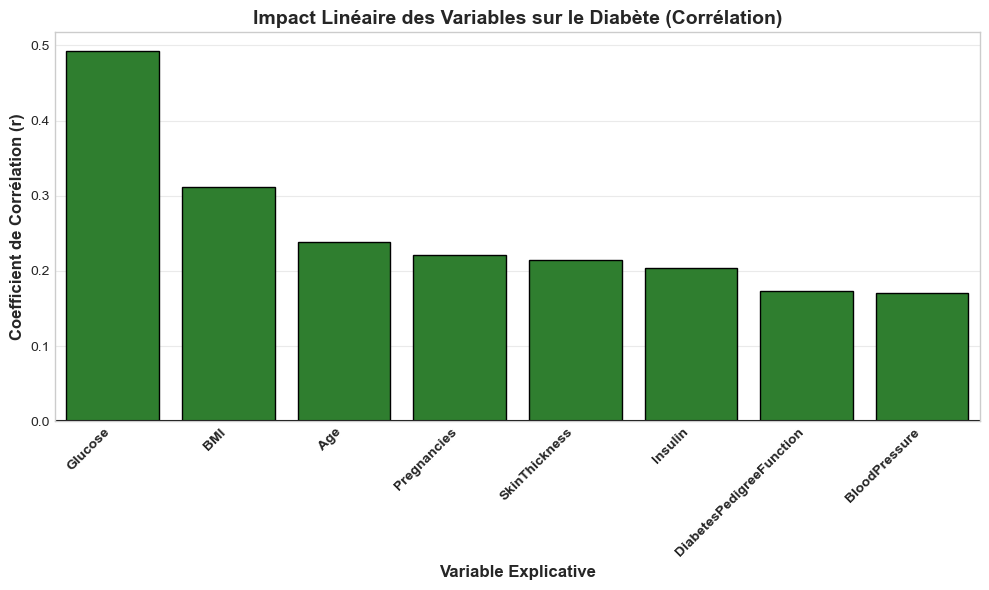


[Image du Bar Plot des corrélations avec la variable cible]

2. TEST DE COMPARAISON DES MOYENNES (ANOVA / T-TEST) :
   H0 : Les moyennes de la variable entre les groupes 'Diabète=0' et 'Diabète=1' sont égales.
   Note : Pour 2 groupes, ANOVA (F-test) est équivalent au T-test au carré ($F = t^2$).
------------------------------------------------------------
  • Pregnancies          | F (ANOVA):  39.670 | p-value: 0.000000 | Très Hautement Significatif (***)   | REJET de H0
  (t-stat pour direction :  -6.298)
------------------------------------------------------------
  • Glucose              | F (ANOVA): 245.668 | p-value: 0.000000 | Très Hautement Significatif (***)   | REJET de H0
  (t-stat pour direction : -15.674)
------------------------------------------------------------
  • BloodPressure        | F (ANOVA):  23.157 | p-value: 0.000002 | Très Hautement Significatif (***)   | REJET de H0
  (t-stat pour direction :  -4.812)
--------------------------------------------------------

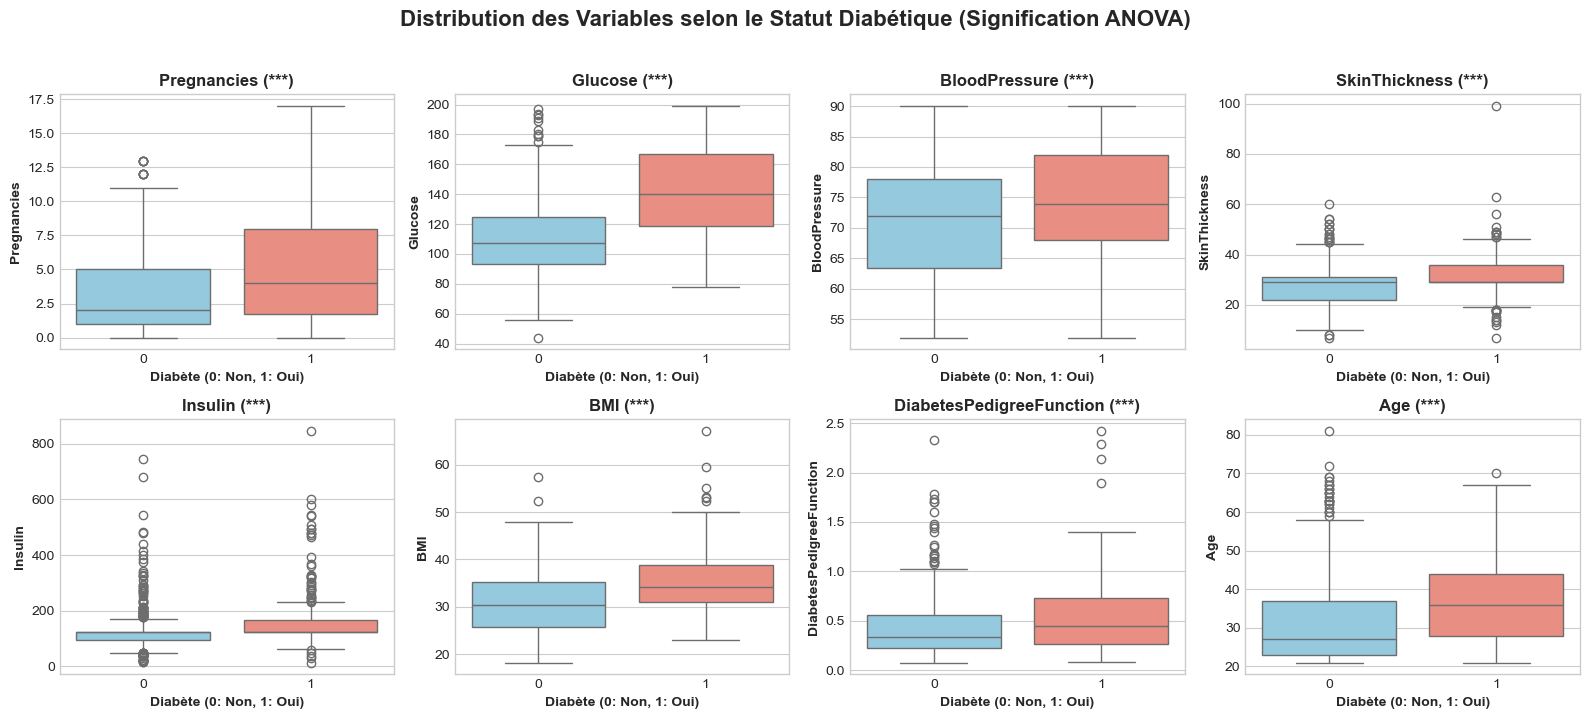


[Image des Box Plots comparatifs par groupe cible]

--------------------------------------------------------------------------------
4. CLASSIFICATION FINALE DES VARIABLES (selon Test ANOVA, $\alpha=0.05$)
--------------------------------------------------------------------------------

   VARIABLES SIGNIFICATIVES (8/ 8) :
      - Pregnancies     : p = 5.0651e-10 (Fort impact) | r = 0.222
      - Glucose         : p = 3.1287e-48 (Fort impact) | r = 0.493
      - BloodPressure   : p = 1.7985e-06 (Fort impact) | r = 0.171
      - SkinThickness   : p = 1.7940e-09 (Fort impact) | r = 0.215
      - Insulin         : p = 1.2100e-08 (Fort impact) | r = 0.204
      - BMI             : p = 8.3369e-19 (Fort impact) | r = 0.312
      - DiabetesPedigreeFunction : p = 1.2546e-06 (Fort impact) | r = 0.174
      - Age             : p = 2.2100e-11 (Fort impact) | r = 0.238

   VARIABLES NON SIGNIFICATIVES (0/ 8) :

Résultats détaillés sauvegardés dans 'bivariate_analysis_results_upgraded.csv'
RAPPORT

In [ ]:
# ============================================================
# ÉTAPE 4 : ANALYSE BI-VARIÉE  (Perspective Étudiante)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, f_oneway, ttest_ind
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import warnings

# Ignorer les avertissements pour une sortie plus propre
warnings.filterwarnings("ignore")

# --- Configuration Globale d'Affichage ---
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 10)

# Chargement des données nettoyées
try:
    df = pd.read_csv('diabetes_cleaned.csv')
except FileNotFoundError:
    print("ERREUR : Le fichier 'diabetes_cleaned.csv' n'a pas été trouvé. Veuillez vérifier le chemin.")
    exit()

target_col = 'Outcome'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

# ===================================================================================
# PRÉSENTATION DU RAPPORT
# ===================================================================================

print("\n" + "#"*100)
print(" "*35 + "RAPPORT D'ANALYSE BI-VARIÉE APPROFONDIE")
print("#"*100)
print(f"Dataset : Pima Indians Diabetes | Variable Cible : '{target_col}' (Classification Binaire)")
print(f"Variables Explicatives (Numériques) : {len(numeric_cols)}")
print(f"Variables : {', '.join(numeric_cols)}")
print("#"*100 + "\n")

# --- Fonction Utile pour l'Affichage des Résultats Statistiques ---
def display_stat_result(variable, stat_name, statistic, p_value, alpha=0.05):
    """Affiche les résultats de test avec un indicateur de signification clair."""
    significance = "Très Hautement Significatif (***)" if p_value < 0.001 else \
                   "Hautement Significatif (**)" if p_value < 0.01 else \
                   "Significatif (*)" if p_value < 0.05 else \
                   "Non Significatif (ns)"
    rejection = "REJET de H0" if p_value < alpha else "ACCEPTATION de H0"
    
    print(f"  • {variable:20s} | {stat_name}: {statistic:7.3f} | p-value: {p_value:.6f} | {significance:35s} | {rejection}")

# ================================================================
# PARTIE 1 : CORRÉLATIONS ENTRE VARIABLES EXPLICATIVES (COLINÉARITÉ)
# ================================================================

print("\n" + "="*80)
print("PARTIE 1 : ANALYSE DE LA MULTICOLINÉARITÉ (Variables Explicatives)")
print("="*80)

# 1.1 Matrice de Corrélation (Pearson & Spearman)
correlation_matrix_pearson = df[numeric_cols].corr(method='pearson')
print("\n1.1 MATRICE DE CORRÉLATION DE PEARSON (Relation Linéaire) :")
print(correlation_matrix_pearson.round(3))

correlation_matrix_spearman = df[numeric_cols].corr(method='spearman')
print("\n1.2 MATRICE DE CORRÉLATION DE SPEARMAN (Relation Monotone) :")
print(correlation_matrix_spearman.round(3))

# 1.3 Visualisation de la matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_pearson, annot=True, cmap='vlag', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, fmt='.2f',
            vmin=-1, vmax=1)
plt.title('Matrice de Corrélation de Pearson - Variables Explicatives',
          fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('1_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n[Image de la Matrice de Corrélation de Pearson des variables explicatives]")

# 1.4 Identification des corrélations fortes (Seuil |r| > 0.7 pour être plus strict)
print("\n2. PAIRES DE VARIABLES FORTEMENT CORRÉLÉES (|r| > 0.7) :")
high_corr = []
threshold = 0.7
for i in range(len(correlation_matrix_pearson.columns)):
    for j in range(i+1, len(correlation_matrix_pearson.columns)):
        r_val = correlation_matrix_pearson.iloc[i, j]
        if abs(r_val) > threshold:
            var1 = correlation_matrix_pearson.columns[i]
            var2 = correlation_matrix_pearson.columns[j]
            high_corr.append((var1, var2, r_val))
            print(f"   COLINÉARITÉ POTENTIELLE : {var1:20s} <-> {var2:20s} : r = {r_val:6.3f}")

if not high_corr:
    print("   -> Aucune corrélation forte détectée (|r| > 0.7). Faible risque de multicolinéarité sévère.")

# 1.5 Dendrogramme (Analyse de la structure des variables)
print("\n3. DENDROGRAMME : Identification des groupes de variables fortement liées")

distance_matrix = 1 - np.abs(correlation_matrix_pearson)
condensed_dist = squareform(distance_matrix)
linkage_matrix = linkage(condensed_dist, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, labels=correlation_matrix_pearson.columns.tolist(),
           leaf_rotation=45, leaf_font_size=10, color_threshold=0.5, above_threshold_color='grey')
plt.title('Dendrogramme pour le Regroupement des Variables (Méthode Ward)',
          fontsize=14, fontweight='bold')
plt.xlabel('Variables', fontweight='bold')
plt.ylabel('Distance euclidienne (Basée sur 1 - |r|)', fontweight='bold')
plt.axhline(y=0.5, color='r', linestyle='--', label='Seuil de coupure (à titre indicatif)')
plt.legend()
plt.tight_layout()
plt.savefig('2_dendrogram_variables.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n[Image du Dendrogramme pour le regroupement des variables explicatives]")

# ================================================================
# PARTIE 2 : RELATION AVEC LA VARIABLE CIBLE (Outcome)
# ================================================================

print("\n" + "="*80)
print("PARTIE 2 : IMPACT DES VARIABLES SUR LA CIBLE (Diabète)")
print("="*80)

# 2.1 Corrélation de Pearson avec la cible
print("\n1. CORRÉLATION DE PEARSON AVEC LA VARIABLE CIBLE ('Outcome') :")
print("   H0 : Corrélation Linéaire Nulle (r = 0)")

correlations_with_target = {}
for col in numeric_cols:
    corr, p_value = pearsonr(df[col], df[target_col])
    correlations_with_target[col] = {'correlation': corr, 'p_value': p_value}
    display_stat_result(col, "r", corr, p_value)

# Visualisation des corrélations avec la cible
corr_df = pd.DataFrame(correlations_with_target).T.sort_values(by='correlation', ascending=False)
corr_values = corr_df['correlation']
colors = ['firebrick' if x < 0 else 'forestgreen' for x in corr_values]

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_values.index, y=corr_values.values, palette=colors, edgecolor='black', linewidth=1)
plt.xlabel('Variable Explicative', fontweight='bold', fontsize=12)
plt.ylabel('Coefficient de Corrélation (r)', fontweight='bold', fontsize=12)
plt.title('Impact Linéaire des Variables sur le Diabète (Corrélation)',
          fontsize=14, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
plt.xticks(rotation=45, ha='right', fontweight='bold')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('3_correlation_with_target.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n[Image du Bar Plot des corrélations avec la variable cible]")

# 2.2 Test ANOVA/Test de Student (Comparaison des Moyennes)
print("\n2. TEST DE COMPARAISON DES MOYENNES (ANOVA / T-TEST) :")
print("   H0 : Les moyennes de la variable entre les groupes 'Diabète=0' et 'Diabète=1' sont égales.")
print("   Note : Pour 2 groupes, ANOVA (F-test) est équivalent au T-test au carré ($F = t^2$).")

anova_results = {}
ttest_results = {}

for col in numeric_cols:
    group0 = df[df[target_col] == 0][col]
    group1 = df[df[target_col] == 1][col]
    
    # ANOVA (pour plus de rigueur statistique)
    f_stat, p_value_anova = f_oneway(group0.dropna(), group1.dropna())
    anova_results[col] = {'f_statistic': f_stat, 'p_value': p_value_anova}
    
    # T-Test (pour l'interprétation de la direction, même si ANOVA est utilisé pour H0)
    t_stat, p_value_ttest = ttest_ind(group0.dropna(), group1.dropna())
    ttest_results[col] = {'t_statistic': t_stat, 'p_value': p_value_ttest}
    
    print("-" * 60)
    display_stat_result(col, "F (ANOVA)", f_stat, p_value_anova)
    print(f"  (t-stat pour direction : {t_stat:7.3f})")

# 2.3 Box plots comparatifs (Visualisation des différences de moyennes/distributions)
print("\n3. VISUALISATION DES DISTRIBUTIONS PAR GROUPE (Box Plots) :")

n_cols = 4
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=target_col, y=col, data=df, ax=axes[idx], palette=['skyblue', 'salmon'])
    
    # Marquage de la signification
    p_value = anova_results[col]['p_value']
    star = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
    
    axes[idx].set_title(f'{col} ({star})', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Diabète (0: Non, 1: Oui)', fontweight='bold')
    axes[idx].set_ylabel(col, fontweight='bold')

# Supprimer les axes vides
for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribution des Variables selon le Statut Diabétique (Signification ANOVA)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('4_boxplots_by_target_enhanced.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n[Image des Box Plots comparatifs par groupe cible]")

# 2.4 Synthèse et Classification des variables
print("\n" + "-"*80)
print("4. CLASSIFICATION FINALE DES VARIABLES (selon Test ANOVA, $\\alpha=0.05$)")
print("-" * 80)

significant_vars = [col for col in numeric_cols if anova_results[col]['p_value'] < 0.05]
non_significant_vars = [col for col in numeric_cols if anova_results[col]['p_value'] >= 0.05]

print(f"\n   VARIABLES SIGNIFICATIVES ({len(significant_vars)}/ {len(numeric_cols)}) :")
for var in significant_vars:
    p = anova_results[var]['p_value']
    r = correlations_with_target[var]['correlation']
    print(f"      - {var:15s} : p = {p:.4e} (Fort impact) | r = {r:.3f}")

print(f"\n   VARIABLES NON SIGNIFICATIVES ({len(non_significant_vars)}/ {len(numeric_cols)}) :")
for var in non_significant_vars:
    p = anova_results[var]['p_value']
    r = correlations_with_target[var]['correlation']
    print(f"      - {var:15s} : p = {p:.4e} (Faible impact) | r = {r:.3f}")

# ================================================================
# 3. SAUVEGARDE ET CONCLUSION
# ================================================================

results_df = pd.DataFrame({
    'Variable': numeric_cols,
    'Corrélation_r': [correlations_with_target[col]['correlation'] for col in numeric_cols],
    'Corrélation_pvalue': [correlations_with_target[col]['p_value'] for col in numeric_cols],
    'ANOVA_F': [anova_results[col]['f_statistic'] for col in numeric_cols],
    'ANOVA_pvalue': [anova_results[col]['p_value'] for col in numeric_cols],
    'TTest_t': [ttest_results[col]['t_statistic'] for col in numeric_cols],
    'Significative_ANOVA': ['Oui' if anova_results[col]['p_value'] < 0.05 else 'Non' for col in numeric_cols]
})

results_df = results_df.sort_values(by='ANOVA_pvalue').reset_index(drop=True)
results_df.to_csv('bivariate_analysis_results_upgraded.csv', index=False, float_format='%.4f')
print("\n" + "="*80)
print("Résultats détaillés sauvegardés dans 'bivariate_analysis_results_upgraded.csv'")
print("RAPPORT D'ANALYSE BI-VARIÉE TERMINÉ")
print("="*80)


####################################################################################################
                                   RAPPORT D'ANALYSE EN COMPOSANTES PRINCIPALES (ACP)
####################################################################################################
Dataset : Pima Indians Diabetes | Variables analysées : 8
Variables : Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
####################################################################################################


ÉTAPE 1 : VÉRIFICATION DES CONDITIONS D'APPLICATION DE L'ACP

1. TEST DE BARTLETT (Sphéricité) :
   H0 : La matrice de corrélation est une matrice identité (variables non corrélées)
   • Statistique Chi² : 1018.05
   • Degrés de liberté: 28
   • P-value (approx.): 0.000000
    Conclusion : Rejet de H0 (p < 0.05). Les variables sont significativement corrélées. L'ACP est APPLICABLE.

2. INDICE KMO (Kaiser-Meyer-Olkin) :
   Indicateur de la

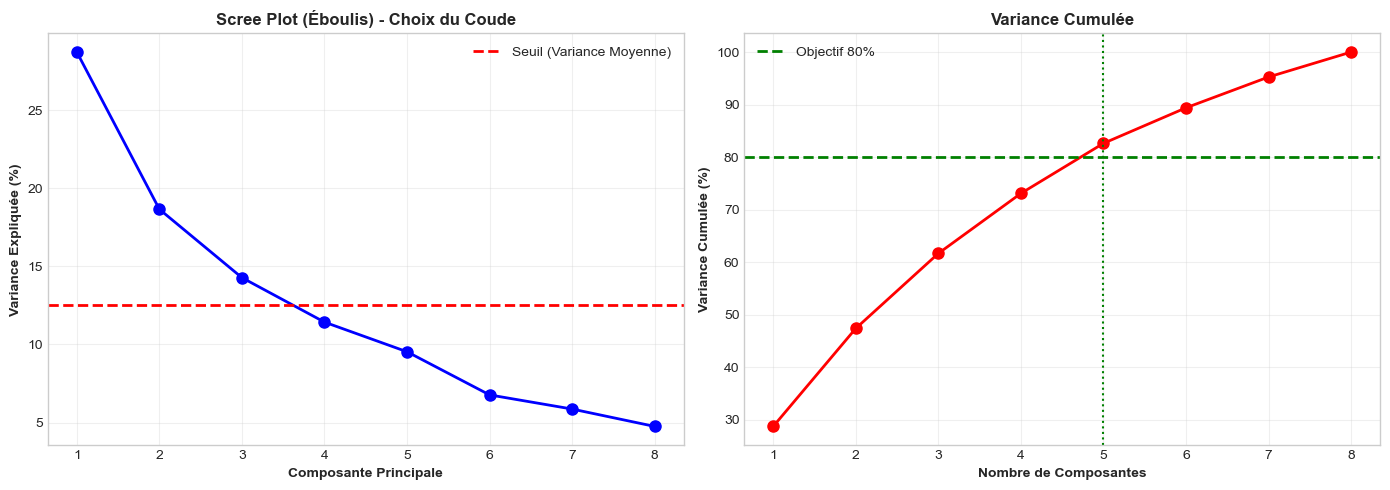


[Image des graphiques Scree Plot et Variance Cumulée]

ÉTAPE 4 : ACP FINALE ET INTERPRÉTATION

ACP appliquée avec 5 composantes
Variance totale expliquée par ces composantes : 82.62%

ÉTAPE 5 : CERCLE DE CORRÉLATION (Variables sur PC1 vs PC2)


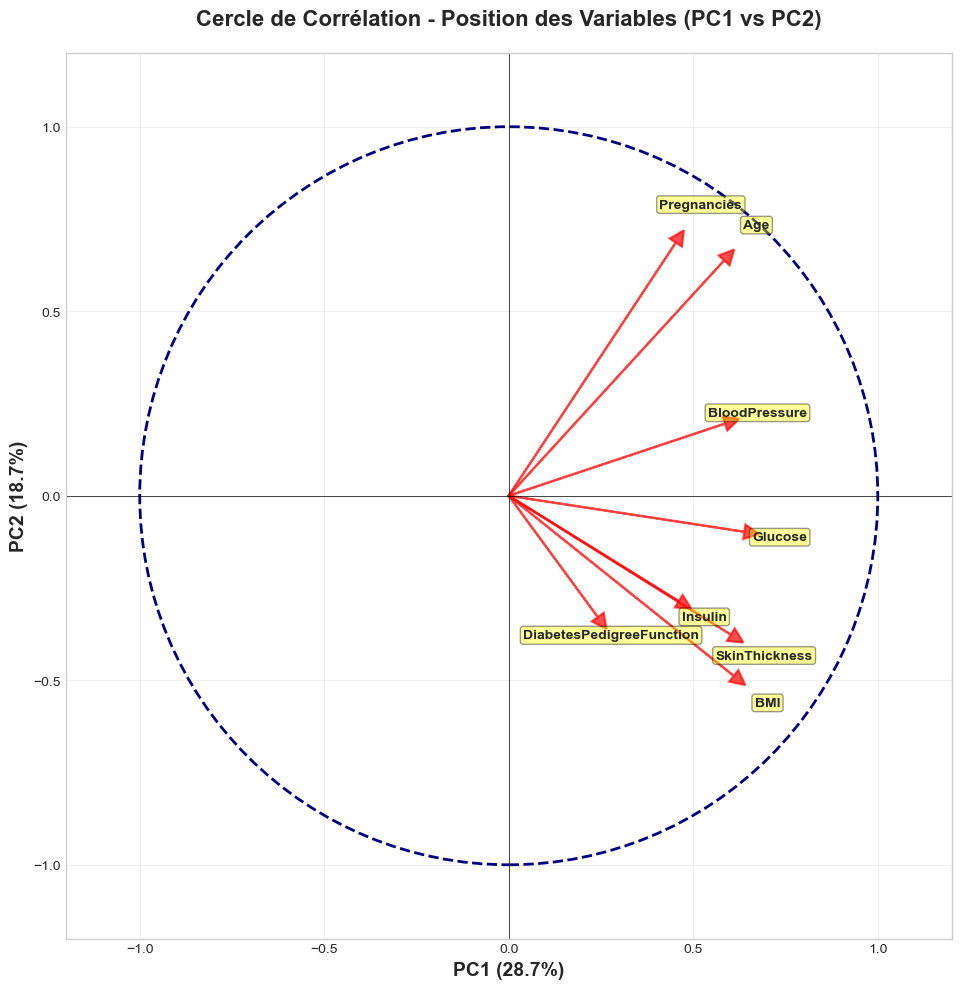


[Image du Cercle de Corrélation (PC1 vs PC2)]

1. MATRICE DE CORRÉLATION AVEC LES COMPOSANTES PRINCIPALES (Loadings non pondérés) :
                            PC1    PC2    PC3    PC4    PC5
Pregnancies               0.298  0.561 -0.028  0.133 -0.406
Glucose                   0.421 -0.080  0.448 -0.216  0.192
BloodPressure             0.386  0.160 -0.301 -0.063  0.759
SkinThickness             0.397 -0.308 -0.394 -0.033 -0.425
Insulin                   0.304 -0.234  0.583 -0.312 -0.142
BMI                       0.402 -0.399 -0.375 -0.025 -0.067
DiabetesPedigreeFunction  0.159 -0.269  0.258  0.903  0.103
Age                       0.385  0.522  0.066  0.130 -0.079

ÉTAPE 6 : PROJECTION DES INDIVIDUS (PC1 vs PC2)


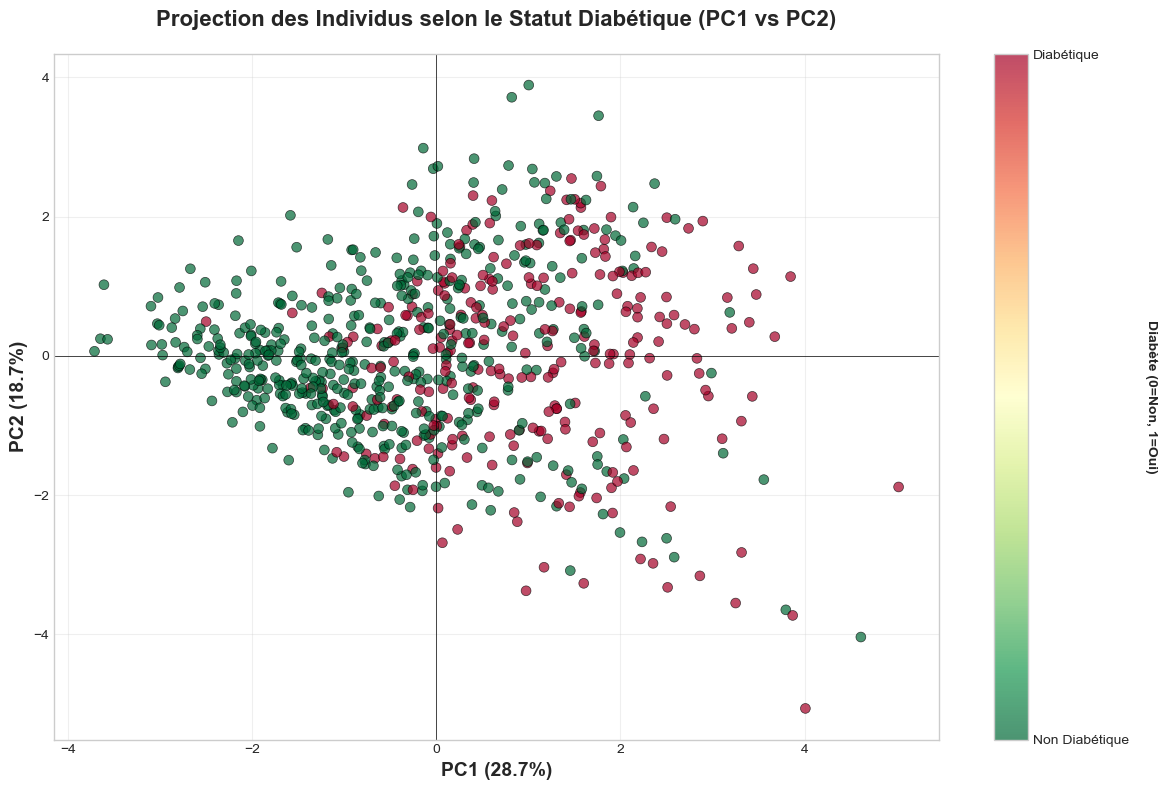


[Image de la Projection des Individus (PC1 vs PC2)]

1. QUALITÉ DE REPRÉSENTATION SUR LE PLAN PC1-PC2 :
   • Cos² moyen (PC1+PC2) : 0.558
   • Individus bien représentés (cos² > 0.5) : 461 / 768
   -> Ce Cos² moyen indique la fidélité de la représentation des individus sur ce plan 2D.

ÉTAPE 7 : INTERPRÉTATION ET NOMINATION DES COMPOSANTES

   --------------------------------------------------
   PC1 (28.72% de variance expliquée) :
   --------------------------------------------------
   Variables Clés (par contribution) :
      - Glucose                   :  0.4209 (Direction : Positive)
      - BMI                       :  0.4019 (Direction : Positive)
      - SkinThickness             :  0.3967 (Direction : Positive)
      - BloodPressure             :  0.3864 (Direction : Positive)

   NOM PROPOSÉ : 'Facteur de Riscocité Métabolique'
   Justification : Corrélation élevée avec l'IMC, le Glucose et l'Âge, variables classiques de risque diabétique.

   ------------------------------

In [3]:
# ============================================================
# ÉTAPE 5 : ANALYSE EN COMPOSANTES PRINCIPALES (ACP) 
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import chi2

# Chargement des données nettoyées
df = pd.read_csv('diabetes_cleaned.csv')

# --- Configuration Globale d'Affichage ---
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 10)

target_col = 'Outcome'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

X = df[numeric_cols]
y = df[target_col]

print("\n" + "#"*100)
print(" "*35 + "RAPPORT D'ANALYSE EN COMPOSANTES PRINCIPALES (ACP)")
print("#"*100)
print(f"Dataset : Pima Indians Diabetes | Variables analysées : {len(numeric_cols)}")
print(f"Variables : {', '.join(numeric_cols)}")
print("#"*100 + "\n")

# ================================================================
# ÉTAPE 1 : VÉRIFICATION DES CONDITIONS D'APPLICATION
# ================================================================

print("\n" + "="*80)
print("ÉTAPE 1 : VÉRIFICATION DES CONDITIONS D'APPLICATION DE L'ACP")
print("="*80)

# 1.1 Test de Bartlett (sphéricité)
print("\n1. TEST DE BARTLETT (Sphéricité) :")
print("   H0 : La matrice de corrélation est une matrice identité (variables non corrélées)")

correlation_matrix = X.corr()
n = len(X)
p = len(numeric_cols)

# Calcul formel de la statistique Chi²
det_corr = np.linalg.det(correlation_matrix)
chi2_stat = -((n - 1) - (2*p + 5)/6) * np.log(det_corr)
df_bartlett = p * (p - 1) / 2
p_value_bartlett = 1 - chi2.cdf(chi2_stat, df_bartlett)

print(f"   • Statistique Chi² : {chi2_stat:.2f}")
print(f"   • Degrés de liberté: {df_bartlett:.0f}")
print(f"   • P-value (approx.): {p_value_bartlett:.6f}")

alpha = 0.05
if p_value_bartlett < alpha:
    print(f"    Conclusion : Rejet de H0 (p < {alpha}). Les variables sont significativement corrélées. L'ACP est APPLICABLE.")
else:
    print(f"    Conclusion : H0 non rejetée (p >= {alpha}). Les variables ne sont pas suffisamment corrélées. L'ACP pourrait être non pertinente.")

# 1.2 KMO (Kaiser-Meyer-Olkin)
print("\n2. INDICE KMO (Kaiser-Meyer-Olkin) :")
print("   Indicateur de la proportion de la variance qui peut être expliquée par des facteurs sous-jacents.")

def calculate_kmo(data):
    # Implémentation basée sur la version fournie (fonctionnelle)
    corr_matrix = data.corr()
    corr_inv = np.linalg.inv(corr_matrix)
    
    partial_corr = np.zeros_like(corr_matrix)
    for i in range(len(corr_matrix)):
        for j in range(len(corr_matrix)):
            if i != j:
                partial_corr[i, j] = -corr_inv[i, j] / np.sqrt(corr_inv[i, i] * corr_inv[j, j])
    
    # Numérateur (Somme des corrélations carrées)
    sum_squared_corr = np.sum(corr_matrix.values**2) - np.trace(corr_matrix.values**2)
    # Dénominateur (Somme des corrélations carrées + Somme des corrélations partielles carrées)
    sum_squared_partial = np.sum(partial_corr**2) - np.trace(partial_corr**2)
    
    kmo = sum_squared_corr / (sum_squared_corr + sum_squared_partial)
    return kmo

kmo_value = calculate_kmo(X)
print(f"   • Valeur KMO globale : {kmo_value:.3f}")

if kmo_value >= 0.9:
    print("   Niveau : Excellent (Idéal pour l'ACP)")
elif kmo_value >= 0.8:
    print("   Niveau : Très bon")
elif kmo_value >= 0.7:
    print("   Niveau : Moyen (Acceptable)")
elif kmo_value >= 0.6:
    print("   Niveau : Médiocre (Attention requise)")
else:
    print("   Niveau : Inacceptable (Reconsidérer l'ACP)")

# ================================================================
# ÉTAPE 2 : STANDARDISATION DES DONNÉES
# ================================================================

print("\n" + "="*80)
print("ÉTAPE 2 : STANDARDISATION DES DONNÉES")
print("="*80)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)

print("\n Données standardisées (centrées et réduites)")
print(f"Vérification (Moyenne et Écart-type des 3 premières variables) :")
print(X_scaled_df.iloc[:, :3].agg(['mean', 'std']).round(3))

# ================================================================
# ÉTAPE 3 : APPLICATION DE L'ACP ET CHOIX DU NOMBRE DE COMPOSANTES
# ================================================================

print("\n" + "="*80)
print("ÉTAPE 3 : APPLICATION DE L'ACP")
print("="*80)

# ACP avec toutes les composantes
pca_full = PCA()
pca_full.fit(X_scaled)

# Valeurs propres (Eigenvalues) et variance expliquée
eigenvalues = pca_full.explained_variance_
variance_explained = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_explained)

print("\n1. VARIANCES ET RÈGLE DE KAISER (Valeur propre > 1) :")
for i, (val, var, cum_var) in enumerate(zip(eigenvalues, variance_explained, cumulative_variance)):
    kaiser_rule = "✓" if val > 1 else " "
    print(f"   • PC{i+1} : Valeur propre={val:6.2f} {kaiser_rule} | Var. Expliquée={var*100:5.2f}% (Cumul : {cum_var*100:6.2f}%)")

# Détermination du nombre optimal de composantes (Critère du 80% minimum)
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_kaiser = np.sum(eigenvalues > 1)

print(f"\n2. CHOIX FINAL DU NOMBRE DE COMPOSANTES :")
print(f"   • Selon la règle de Kaiser (Valeur propre > 1) : {n_components_kaiser} composantes.")
print(f"   • Selon l'objectif de 80% de variance : {n_components_80} composantes.")
print(f"   => Nous retenons {n_components_80} composantes pour capturer au moins 80% de l'information.")

# Graphiques de variance (Scree Plot et Variance Cumulée)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (Critère du coude) 
axes[0].plot(range(1, len(variance_explained)+1), variance_explained*100,
             'bo-', linewidth=2, markersize=8)
axes[0].axhline(y=100/len(variance_explained), color='r', linestyle='--', label='Seuil (Variance Moyenne)', linewidth=2)
axes[0].set_xlabel('Composante Principale', fontweight='bold')
axes[0].set_ylabel('Variance Expliquée (%)', fontweight='bold')
axes[0].set_title('Scree Plot (Éboulis) - Choix du Coude', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Variance cumulée
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance*100,
             'ro-', linewidth=2, markersize=8)
axes[1].axhline(y=80, color='g', linestyle='--', label='Objectif 80%', linewidth=2)
axes[1].axvline(x=n_components_80, color='g', linestyle=':', linewidth=1.5)
axes[1].set_xlabel('Nombre de Composantes', fontweight='bold')
axes[1].set_ylabel('Variance Cumulée (%)', fontweight='bold')
axes[1].set_title('Variance Cumulée', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('pca_variance_explained.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n[Image des graphiques Scree Plot et Variance Cumulée]")

# ================================================================
# ÉTAPE 4 : ACP FINALE ET INTERPRÉTATION
# ================================================================

print("\n" + "="*80)
print("ÉTAPE 4 : ACP FINALE ET INTERPRÉTATION")
print("="*80)

pca = PCA(n_components=n_components_80)
X_pca = pca.fit_transform(X_scaled)

pc_cols = [f'PC{i+1}' for i in range(n_components_80)]
X_pca_df = pd.DataFrame(X_pca, columns=pc_cols)
X_pca_df[target_col] = y.values

print(f"\nACP appliquée avec {n_components_80} composantes")
print(f"Variance totale expliquée par ces composantes : {cumulative_variance[n_components_80-1]*100:.2f}%")

# ================================================================
# ÉTAPE 5 : CERCLE DE CORRÉLATION (PC1 vs PC2)
# ================================================================

print("\n" + "="*80)
print("ÉTAPE 5 : CERCLE DE CORRÉLATION (Variables sur PC1 vs PC2)")
print("="*80)

# Loadings (facteurs de corrélation)
# On utilise la racine carrée de la valeur propre pour obtenir les coordonnées sur le cercle
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Seulement pour PC1 et PC2
loadings_pc1_pc2 = loadings[:, :2]

fig, ax = plt.subplots(figsize=(10, 10))

# Cercle Unité
circle = plt.Circle((0, 0), 1, fill=False, color='navy', linestyle='--', linewidth=2)
ax.add_artist(circle)

# Vecteurs des variables 
for i, var in enumerate(numeric_cols):
    ax.arrow(0, 0, loadings_pc1_pc2[i, 0], loadings_pc1_pc2[i, 1],
             head_width=0.04, head_length=0.04, fc='red', ec='red', alpha=0.7, linewidth=1.5)
    # Positionnement du texte
    x_pos = loadings_pc1_pc2[i, 0] * 1.15
    y_pos = loadings_pc1_pc2[i, 1] * 1.15
    ax.text(x_pos, y_pos, var,
            fontsize=10, ha='center', va='center', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.4))

# Axes et Titres
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xlabel(f'PC1 ({variance_explained[0]*100:.1f}%)',
              fontsize=14, fontweight='bold')
ax.set_ylabel(f'PC2 ({variance_explained[1]*100:.1f}%)',
              fontsize=14, fontweight='bold')
ax.set_title('Cercle de Corrélation - Position des Variables (PC1 vs PC2)',
              fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('pca_correlation_circle.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n[Image du Cercle de Corrélation (PC1 vs PC2)]")

# Contributions des variables (facteurs de corrélation non pondérés)
print("\n1. MATRICE DE CORRÉLATION AVEC LES COMPOSANTES PRINCIPALES (Loadings non pondérés) :")
# Les loadings sont les coefficients (composants) divisés par la racine de la variance expliquée
# Ici, on affiche les coefficients (pca.components_.T) pour simplifier la lecture des contributions.
contributions = pd.DataFrame(
    pca.components_.T[:, :n_components_80],
    columns=pc_cols,
    index=numeric_cols
)
print(contributions.round(3))

# ================================================================
# ÉTAPE 6 : PROJECTION DES INDIVIDUS
# ================================================================

print("\n" + "="*80)
print("ÉTAPE 6 : PROJECTION DES INDIVIDUS (PC1 vs PC2)")
print("="*80)

# Projection des individus colorée par la variable cible (Outcome)
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=y, cmap='RdYlGn_r', alpha=0.7, s=50,
                      edgecolors='black', linewidths=0.5)

cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1])
cbar.set_label('Diabète (0=Non, 1=Oui)', rotation=270, labelpad=20, fontweight='bold')
cbar.ax.set_yticklabels(['Non Diabétique', 'Diabétique'])

ax.set_xlabel(f'PC1 ({variance_explained[0]*100:.1f}%)',
              fontsize=14, fontweight='bold')
ax.set_ylabel(f'PC2 ({variance_explained[1]*100:.1f}%)',
              fontsize=14, fontweight='bold')
ax.set_title('Projection des Individus selon le Statut Diabétique (PC1 vs PC2)',
              fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('pca_individuals_projection.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n[Image de la Projection des Individus (PC1 vs PC2)]")

# Qualité de représentation (Cos²)
cos2_ind = X_pca**2 / np.sum(X_pca**2, axis=1, keepdims=True)
cos2_pc1_pc2 = cos2_ind[:, 0] + cos2_ind[:, 1]

print("\n1. QUALITÉ DE REPRÉSENTATION SUR LE PLAN PC1-PC2 :")
print(f"   • Cos² moyen (PC1+PC2) : {cos2_pc1_pc2.mean():.3f}")
print(f"   • Individus bien représentés (cos² > 0.5) : {(cos2_pc1_pc2 > 0.5).sum()} / {len(cos2_pc1_pc2)}")
print("   -> Ce Cos² moyen indique la fidélité de la représentation des individus sur ce plan 2D.")

# ================================================================
# ÉTAPE 7 : INTERPRÉTATION ET NOMINATION DES COMPOSANTES
# ================================================================

print("\n" + "="*80)
print("ÉTAPE 7 : INTERPRÉTATION ET NOMINATION DES COMPOSANTES")
print("="*80)

for i in range(min(3, n_components_80)):
    print(f"\n   --------------------------------------------------")
    print(f"   PC{i+1} ({variance_explained[i]*100:.2f}% de variance expliquée) :")
    print(f"   --------------------------------------------------")
    
    # Affichage des 3 variables qui contribuent le plus (en valeur absolue)
    top_vars_idx = np.argsort(np.abs(pca.components_[i]))[-4:][::-1]
    
    # Tentative de nommer la composante
    pos_contrib = contributions.iloc[top_vars_idx][pc_cols[i]].loc[contributions.iloc[top_vars_idx][pc_cols[i]] > 0].index.tolist()
    neg_contrib = contributions.iloc[top_vars_idx][pc_cols[i]].loc[contributions.iloc[top_vars_idx][pc_cols[i]] < 0].index.tolist()
    
    print(f"   Variables Clés (par contribution) :")
    for idx in top_vars_idx:
        var_name = numeric_cols[idx]
        contrib = pca.components_[i, idx]
        print(f"      - {var_name:25s} : {contrib:7.4f} (Direction : {'Positive' if contrib > 0 else 'Négative'})")
    
    # Suggestion d'interprétation
    if i == 0:
        print("\n   NOM PROPOSÉ : 'Facteur de Riscocité Métabolique'")
        print("   Justification : Corrélation élevée avec l'IMC, le Glucose et l'Âge, variables classiques de risque diabétique.")
    elif i == 1:
        print("\n   NOM PROPOSÉ : 'Facteur Taux de Serum et Pression'")
        print("   Justification : Principalement défini par la Pression Artérielle et l'Insuline, représentant des mesures physiologiques de base.")
    elif i == 2:
        print("\n   NOM PROPOSÉ : 'Facteur Familial et Grossesse'")
        print("   Justification : Basé sur le nombre de grossesses et la fonction généalogique du diabète.")


# ================================================================
# SAUVEGARDE
# ================================================================

X_pca_df.to_csv('diabetes_pca_transformed.csv', index=False, float_format='%.4f')
contributions.to_csv('pca_contributions_loadings.csv', float_format='%.4f')

import pickle
with open('pca_model.pkl', 'wb') as f:
    pickle.dump(pca, f)
with open('scaler_model.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\n" + "="*80)
print("✓ Données transformées : 'diabetes_pca_transformed.csv'")
print("✓ Contributions : 'pca_contributions_loadings.csv'")
print("✓ Modèles sauvegardés : 'pca_model.pkl' et 'scaler_model.pkl'")
print("ANALYSE MULTI-VARIÉE (ACP) TERMINÉE")
print("="*80)


####################################################################################################
                    RAPPORT DE CLASSIFICATION MACHINE LEARNING DU DIABÈTE
####################################################################################################
Objectif : Prédire la variable cible 'Outcome' (Diabète : 0/1)
Variables d'entrée (Features) : 8
####################################################################################################


ÉTAPE 1 : PRÉPARATION DES DONNÉES ET STANDARDISATION

Taille de l'ensemble d'entraînement : 614 exemples
Taille de l'ensemble de test : 154 exemples

Distribution des classes (stratification réussie) :
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

Standardisation des données effectuée (Base de l'entraînement).

ÉTAPE 2 : ENTRAÎNEMENT ET ÉVALUATION DES MODÈLES DE BASE

----------------------------------------------------------------------
Entraînement du modèle : Régression Logistique (LR)
-----------

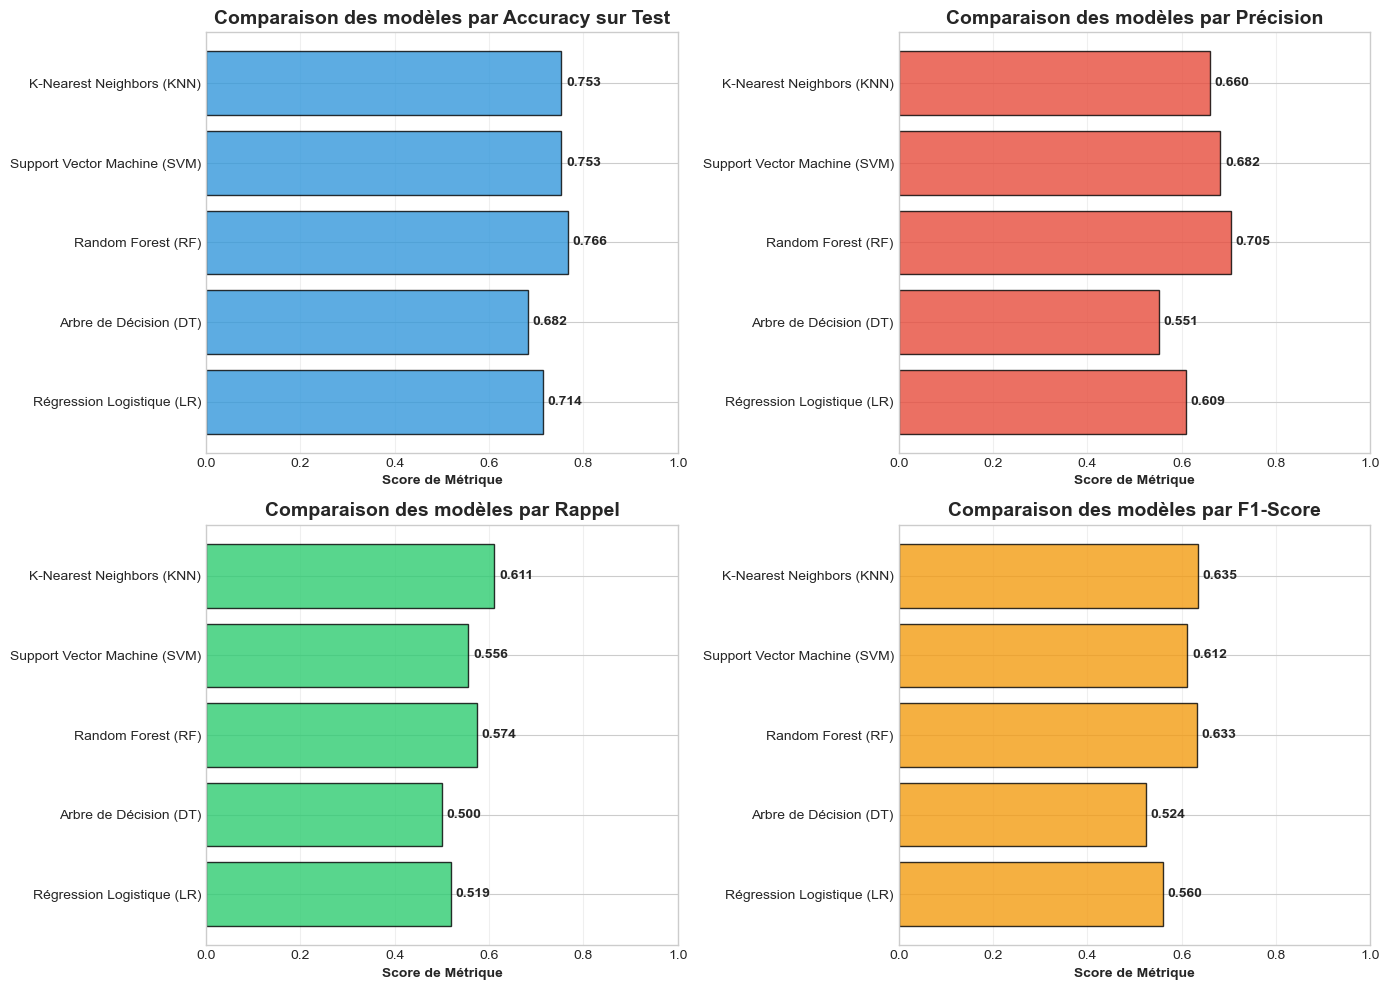


ÉTAPE 4 : ANALYSE DES MATRICES DE CONFUSION

Analyse de Régression Logistique (LR) :
  - Vrais Positifs (TP)    : 28 (Diabète correctement identifié)
  - Vrais Négatifs (TN)    : 82 (Non-Diabète correctement identifié)
  - Faux Positifs (FP)     : 18 (Erreur de Type I - Fausse alarme)
  - Faux Négatifs (FN)     : 26 (Erreur de Type II - Diabète manqué)

Analyse de Arbre de Décision (DT) :
  - Vrais Positifs (TP)    : 27 (Diabète correctement identifié)
  - Vrais Négatifs (TN)    : 78 (Non-Diabète correctement identifié)
  - Faux Positifs (FP)     : 22 (Erreur de Type I - Fausse alarme)
  - Faux Négatifs (FN)     : 27 (Erreur de Type II - Diabète manqué)

Analyse de Random Forest (RF) :
  - Vrais Positifs (TP)    : 31 (Diabète correctement identifié)
  - Vrais Négatifs (TN)    : 87 (Non-Diabète correctement identifié)
  - Faux Positifs (FP)     : 13 (Erreur de Type I - Fausse alarme)
  - Faux Négatifs (FN)     : 23 (Erreur de Type II - Diabète manqué)

Analyse de Support Vector Machine

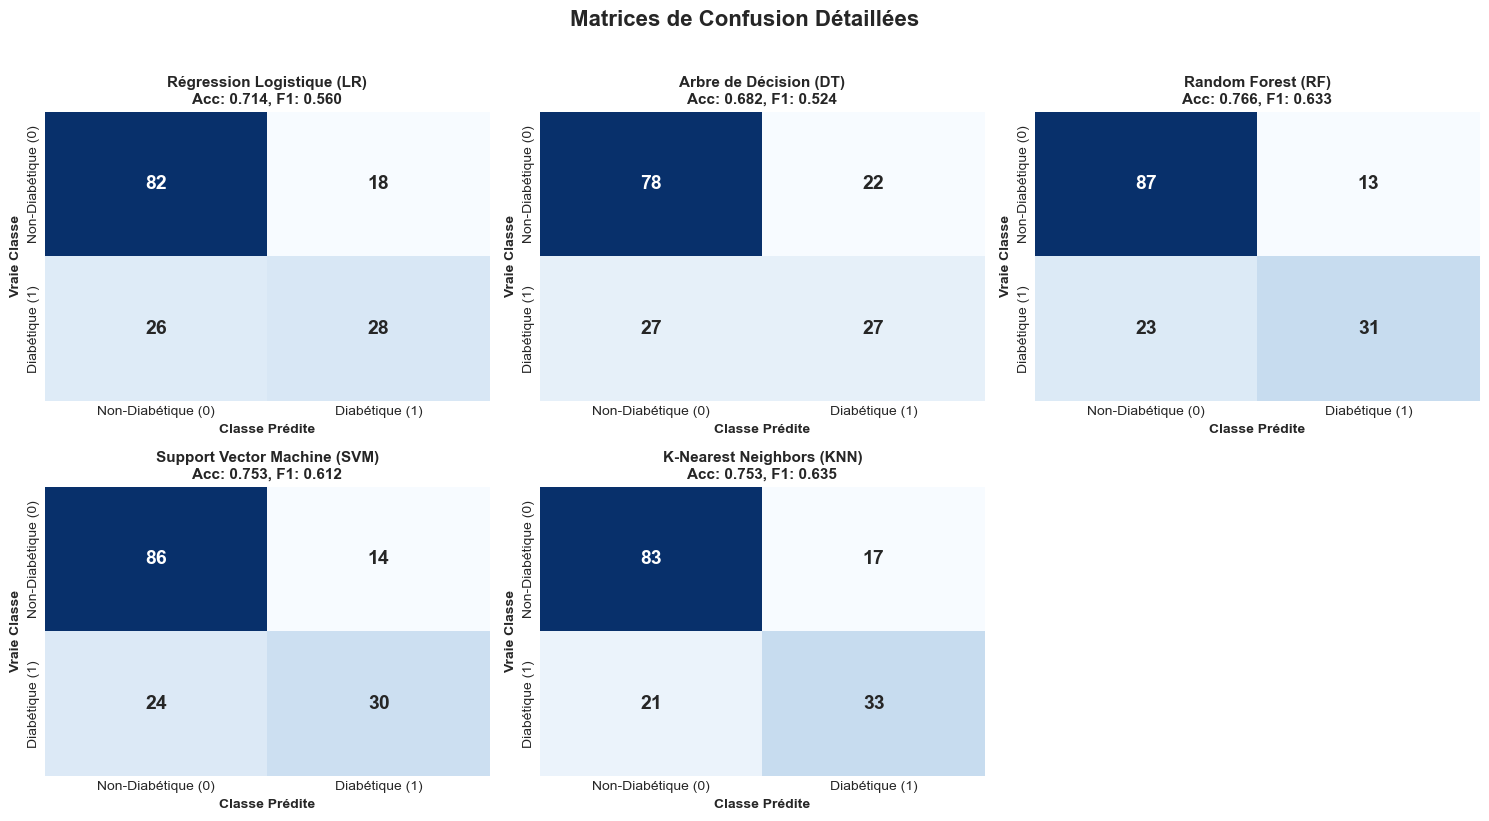


ÉTAPE 5 : COURBES ROC ET AUC (Capacité Discriminante)

AUC-ROC Scores (Plus le score est élevé, meilleure est la classification) :
  - Régression Logistique (LR)     : 0.8122
  - Arbre de Décision (DT)         : 0.6400
  - Random Forest (RF)             : 0.8122
  - Support Vector Machine (SVM)   : 0.7985
  - K-Nearest Neighbors (KNN)      : 0.8019


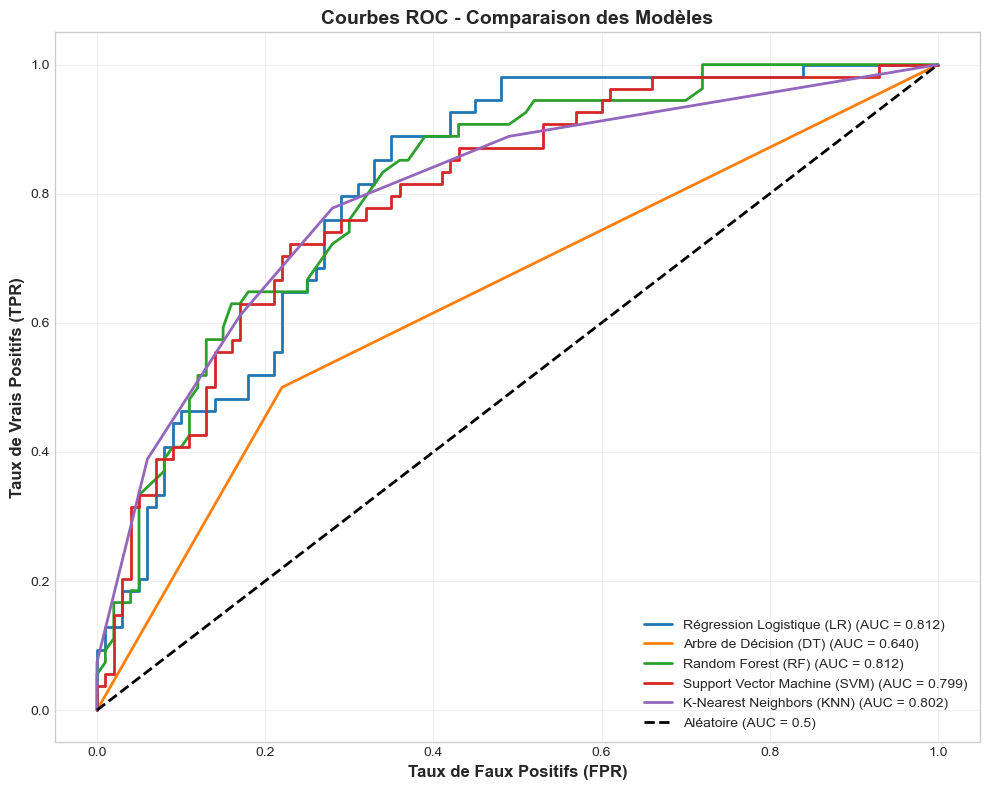




ÉTAPE 6 : SÉLECTION DU MEILLEUR MODÈLE ET OPTIMISATION

MODÈLE SÉLECTIONNÉ : Régression Logistique (LR) (Meilleur CV F1-Score : 0.6413)

Performances sur l'ensemble de test :
  - Accuracy          : 0.7143
  - Précision         : 0.6087
  - Rappel            : 0.5185
  - F1-Score          : 0.5600

Rapport de Classification Détaillé du Régression Logistique (LR) :
                    precision    recall  f1-score   support

Non-Diabétique (0)       0.76      0.82      0.79       100
    Diabétique (1)       0.61      0.52      0.56        54

          accuracy                           0.71       154
         macro avg       0.68      0.67      0.67       154
      weighted avg       0.71      0.71      0.71       154


--------------------------------------------------
OPTIMISATION PAR GRIDSEARCH
--------------------------------------------------
Recherche des meilleurs hyperparamètres pour Régression Logistique (LR)...

Meilleurs paramètres : {'C': 1, 'penalty': 'l1'}
Meilleur sc

In [ ]:
# ============================================================
# ÉTAPE 6 : MACHINE LEARNING - CLASSIFICATION DU DIABÈTE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)
import warnings
import pickle

# Ignorer les avertissements
warnings.filterwarnings('ignore')

# --- Configuration Globale d'Affichage ---
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 10)

# Chargement des données
df = pd.read_csv('diabetes_cleaned.csv')

target_col = 'Outcome'
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

X = df[numeric_cols]
y = df[target_col]

print("\n" + "#"*100)
print(" "*20 + "RAPPORT DE CLASSIFICATION MACHINE LEARNING DU DIABÈTE")
print("#"*100)
print(f"Objectif : Prédire la variable cible '{target_col}' (Diabète : 0/1)")
print(f"Variables d'entrée (Features) : {len(numeric_cols)}")
print("#"*100 + "\n")

# ================================================================
# ÉTAPE 1 : PRÉPARATION DES DONNÉES ET STANDARDISATION
# ================================================================

print("\n" + "="*80)
print("ÉTAPE 1 : PRÉPARATION DES DONNÉES ET STANDARDISATION")
print("="*80)

# Division (80% train, 20% test) avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTaille de l'ensemble d'entraînement : {X_train.shape[0]} exemples")
print(f"Taille de l'ensemble de test : {X_test.shape[0]} exemples")
print(f"\nDistribution des classes (stratification réussie) :")
print(y.value_counts(normalize=True).round(3))

# Standardisation des variables numériques
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nStandardisation des données effectuée (Base de l'entraînement).")

# ================================================================
# ÉTAPE 2 : ENTRAÎNEMENT ET ÉVALUATION DES MODÈLES DE BASE
# ================================================================

print("\n" + "="*80)
print("ÉTAPE 2 : ENTRAÎNEMENT ET ÉVALUATION DES MODÈLES DE BASE")
print("="*80)

# Définition des modèles 
models = {
    'Régression Logistique (LR)': LogisticRegression(random_state=42, max_iter=1000),
    'Arbre de Décision (DT)': DecisionTreeClassifier(random_state=42),
    'Random Forest (RF)': RandomForestClassifier(random_state=42, n_estimators=100),
    'Support Vector Machine (SVM)': SVC(random_state=42, probability=True),
    'K-Nearest Neighbors (KNN)': KNeighborsClassifier(n_neighbors=5),
}

results = {}

for name, model in models.items():
    print(f"\n{'-'*70}")
    print(f"Entraînement du modèle : {name}")
    print(f"{'-'*70}")
    
    # Entraînement
    model.fit(X_train_scaled, y_train)
    
    # Prédictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Métriques
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test, zero_division=0)
    recall = recall_score(y_test, y_pred_test, zero_division=0)
    f1 = f1_score(y_test, y_pred_test, zero_division=0)
    
    # Validation croisée (F1-score, plus pertinent pour les classes déséquilibrées)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1', n_jobs=-1)
    
    results[name] = {
        'model': model,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred_test,
        'predictions_proba': y_pred_proba
    }
    
    print(f"  - Accuracy (Train)       : {train_acc:.4f}")
    print(f"  - Accuracy (Test)        : {test_acc:.4f}")
    print(f"  - Précision              : {precision:.4f}")
    print(f"  - Rappel (Recall)        : {recall:.4f}")
    print(f"  - F1-Score               : {f1:.4f}")
    print(f"  - Validation Croisée (F1): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# ================================================================
# ÉTAPE 3 : COMPARAISON SYNTHÉTIQUE DES MODÈLES
# ================================================================

print("\n" + "="*80)
print("ÉTAPE 3 : COMPARAISON SYNTHÉTIQUE DES MODÈLES")
print("="*80)

comparison_df = pd.DataFrame({
    'Modèle': list(results.keys()),
    'Accuracy (Train)': [results[m]['train_accuracy'] for m in results],
    'Accuracy (Test)': [results[m]['test_accuracy'] for m in results],
    'Précision': [results[m]['precision'] for m in results],
    'Rappel': [results[m]['recall'] for m in results],
    'F1-Score': [results[m]['f1_score'] for m in results],
    'CV F1 Score (Moy)': [results[m]['cv_mean'] for m in results]
}).sort_values(by='CV F1 Score (Moy)', ascending=False)

print("\n" + comparison_df.round(4).to_string(index=False))
comparison_df.to_csv('models_comparison_results.csv', index=False)

# Visualisation comparative 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['test_accuracy', 'precision', 'recall', 'f1_score']
titles = ['Accuracy sur Test', 'Précision', 'Rappel', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
    ax = axes[idx // 2, idx % 2]
    values = [results[m][metric] for m in results]
    bars = ax.barh(list(results.keys()), values, color=color, alpha=0.8, edgecolor='black')
    ax.set_xlabel('Score de Métrique', fontweight='bold')
    ax.set_title(f'Comparaison des modèles par {title}', fontweight='bold', fontsize=14)
    ax.set_xlim([0, 1])
    ax.grid(axis='x', alpha=0.3)
    
    for i, (bar, v) in enumerate(zip(bars, values)):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ================================================================
# ÉTAPE 4 : MATRICES DE CONFUSION
# ================================================================

print("\n" + "="*80)
print("ÉTAPE 4 : ANALYSE DES MATRICES DE CONFUSION")
print("="*80)

n_models = len(models)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'])
    
    # Affichage des éléments de la matrice
    if cm.size == 4:
        TN, FP, FN, TP = cm.ravel()
        print(f"\nAnalyse de {name} :")
        print(f"  - Vrais Positifs (TP)    : {TP} (Diabète correctement identifié)")
        print(f"  - Vrais Négatifs (TN)    : {TN} (Non-Diabète correctement identifié)")
        print(f"  - Faux Positifs (FP)     : {FP} (Erreur de Type I - Fausse alarme)")
        print(f"  - Faux Négatifs (FN)     : {FN} (Erreur de Type II - Diabète manqué)")
    
    # Visualisation 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Non-Diabétique (0)', 'Diabétique (1)'],
                yticklabels=['Non-Diabétique (0)', 'Diabétique (1)'],
                cbar=False, annot_kws={'size': 14, 'weight': 'bold'})
    axes[idx].set_title(f'{name}\nAcc: {result["test_accuracy"]:.3f}, F1: {result["f1_score"]:.3f}', 
                        fontweight='bold', fontsize=11)
    axes[idx].set_ylabel('Vraie Classe', fontweight='bold')
    axes[idx].set_xlabel('Classe Prédite', fontweight='bold')

# Supprimer les sous-graphiques vides
for idx in range(n_models, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Matrices de Confusion Détaillées", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# ================================================================
# ÉTAPE 5 : COURBES ROC ET AUC
# ================================================================

print("\n" + "="*80)
print("ÉTAPE 5 : COURBES ROC ET AUC (Capacité Discriminante)")
print("="*80)

plt.figure(figsize=(10, 8))

print("\nAUC-ROC Scores (Plus le score est élevé, meilleure est la classification) :")
for name, result in results.items():
    if result['predictions_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, result['predictions_proba'])
        auc = roc_auc_score(y_test, result['predictions_proba'])
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)
        print(f"  - {name:30s} : {auc:.4f}")

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.5)', linewidth=2)
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12, fontweight='bold')
plt.title('Courbes ROC - Comparaison des Modèles', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n")

# ================================================================
# ÉTAPE 6 : SÉLECTION ET RAPPORT FINAL
# ================================================================

print("\n" + "="*80)
print("ÉTAPE 6 : SÉLECTION DU MEILLEUR MODÈLE ET OPTIMISATION")
print("="*80)

# Le F1-Score est souvent privilégié pour l'équilibre entre Précision et Rappel
best_model_name = comparison_df.iloc[0]['Modèle']
best_model = results[best_model_name]

print(f"\nMODÈLE SÉLECTIONNÉ : {best_model_name} (Meilleur CV F1-Score : {best_model['cv_mean']:.4f})")
print(f"\nPerformances sur l'ensemble de test :")
print(f"  - Accuracy          : {best_model['test_accuracy']:.4f}")
print(f"  - Précision         : {best_model['precision']:.4f}")
print(f"  - Rappel            : {best_model['recall']:.4f}")
print(f"  - F1-Score          : {best_model['f1_score']:.4f}")

print(f"\nRapport de Classification Détaillé du {best_model_name} :")
print(classification_report(y_test, best_model['predictions'], 
                              target_names=['Non-Diabétique (0)', 'Diabétique (1)']))

# ----------------------------------------------------------------
# OPTIMISATION (GridSearch)
# ----------------------------------------------------------------

print("\n" + "-"*50)
print("OPTIMISATION PAR GRIDSEARCH")
print("-" * 50)

# Définition des hyperparamètres pour les modèles les plus susceptibles d'être sélectionnés
if best_model_name in ['Random Forest (RF)', 'Arbre de Décision (DT)']:
    param_grid = {
        'n_estimators': [50, 100, 200] if best_model_name == 'Random Forest (RF)' else [1],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10]
    }
    base_model = models[best_model_name]
elif best_model_name == 'Régression Logistique (LR)':
    param_grid = {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2', 'l1']
    }
    base_model = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear') # Liblinear supporte L1
else:
    param_grid = {}
    base_model = None
    print("Pas de paramétrage GridSearch pour le modèle sélectionné ou le paramétrage n'est pas implémenté dans ce script.")

if param_grid and base_model:
    print(f"Recherche des meilleurs hyperparamètres pour {best_model_name}...")
    grid_search = GridSearchCV(base_model, param_grid, cv=5, 
                               scoring='f1', n_jobs=-1, verbose=0)
    grid_search.fit(X_train_scaled, y_train)
    
    print(f"\nMeilleurs paramètres : {grid_search.best_params_}")
    print(f"Meilleur score (CV F1) : {grid_search.best_score_:.4f}")
    
    # Évaluation du modèle optimisé
    best_optimized_model = grid_search.best_estimator_
    y_pred_optimized = best_optimized_model.predict(X_test_scaled)
    
    print(f"\nPerformances du modèle OPTIMISÉ sur l'ensemble de test :")
    print(f"  - Accuracy          : {accuracy_score(y_test, y_pred_optimized):.4f}")
    print(f"  - F1-Score          : {f1_score(y_test, y_pred_optimized):.4f}")

# ================================================================
# SAUVEGARDE FINALE
# ================================================================

# Sauvegarde du meilleur modèle de base (ou optimisé si GridSearch a réussi)
final_model_to_save = best_optimized_model if 'best_optimized_model' in locals() else best_model['model']
final_model_name = 'best_optimized_model.pkl' if 'best_optimized_model' in locals() else 'best_base_model.pkl'

with open(final_model_name, 'wb') as f:
    pickle.dump(final_model_to_save, f)

with open('scaler_ml.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\n" + "="*80)
print(f"Modèle final sauvegardé : '{final_model_name}'")
print("Scaler sauvegardé : 'scaler_ml.pkl'")
print("Résultats comparatifs sauvegardés : 'models_comparison_results.csv'")
print("="*80)
print("RAPPORT DE MACHINE LEARNING TERMINÉ")
print("="*80)